In [66]:
from langchain_core.tools import tool
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders  import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from langchain_core.messages import HumanMessage,BaseMessage,AIMessage
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph import add_messages
from langchain_groq import ChatGroq

In [67]:
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv(Path(r"D:\AI\BRAND_BRIDGE") / ".env", override=True)
#google_api_key = os.getenv("GOOGLE_API_KEY")
groq_api_key=os.getenv("GROQ_API_KEY")
database_url = os.getenv("DATABASE_URL")
#print("GOOGLE_API_KEY loaded:", bool(google_api_key))
print("GROQ_API_KEY loaded:",bool(groq_api_key))
print("DATABASE_URL loaded:", bool(database_url))

GROQ_API_KEY loaded: True
DATABASE_URL loaded: True


In [68]:
#llm=ChatGoogleGenerativeAI(model="gemini-3.8-flash",google_api_key=google_api_key)
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY")
)

In [69]:
loader=PyPDFLoader("Vivo_Smartphone_Influencer_Brief_Final.pdf")
docs=loader.load()

In [70]:
len(docs)

3

In [71]:
splitter=RecursiveCharacterTextSplitter(chunk_size=200,chunk_overlap=50)
chunks=splitter.split_documents(docs)
len(chunks)


51

In [72]:
embeddings=GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")


In [73]:
from langchain_postgres import PGVector
from sqlalchemy import create_engine, text

database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise ValueError(
        "DATABASE_URL is empty. Re-run the load_dotenv cell after saving .env."
    )

engine = create_engine(database_url)
with engine.connect() as conn:
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS vector"))
    conn.commit()

print("Connected to PostgreSQL and enabled pgvector.")

Connected to PostgreSQL and enabled pgvector.


In [74]:
vector_store = PGVector(
    embeddings=embeddings,
    collection_name="Vivo_Smartphone",
    connection=database_url,
    use_jsonb=True,
)

In [75]:
docs_to_index = chunks[:20]

batch_size = 20

for i in range(0, len(docs_to_index), batch_size):
    batch = docs_to_index[i:i + batch_size]

    vector_store.add_documents(batch)

    print(
        f"Indexed {min(i + batch_size, len(docs_to_index))}"
        f"/{len(docs_to_index)}"
    )

Indexed 20/20


In [76]:

@tool
def rag_tool(retrieved_chunks: str):
    """
    Extract campaign requirements from retrieved campaign brief chunks.
    Return the requirements in structured JSON format.
    """

    prompt = f"""
    Extract the campaign requirements from the following
    retrieved campaign brief.

    Return ONLY valid JSON.

    Do not invent information that is not present
    in the retrieved content.

    Retrieved content:
    {retrieved_chunks}
    """

    response = llm.invoke(prompt)

    return response.content

In [77]:
results = vector_store.similarity_search(
    "What type of influencers does this campaign require?",
    k=15
)

retrieved_chunks = "\n\n".join(
    doc.page_content for doc in results
)

result = rag_tool.invoke({
    "retrieved_chunks": retrieved_chunks
})

print(result)

{
  "platforms": ["Instagram", "YouTube"],
  "minimum_followers": 50000,
  "minimum_average_views_per_post_video": 20000,
  "minimum_engagement_rate_percent": 4,
  "minimum_average_likes": 1000,
  "minimum_average_comments": 50
}


In [78]:
#tools=[rag_tool]
#llm_with_tool=llm.bind_tools(tools)

In [79]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    query: str
    context: str

In [80]:
def rag_node(state: ChatState):

    results = vector_store.similarity_search(
        state["query"],
        k=15
    )

    retrieved_chunks = "\n\n".join(
        doc.page_content for doc in results
    )

    result = rag_tool.invoke({
        "retrieved_chunks": retrieved_chunks
    })

    return {
        "context": result
    }

In [81]:
def chat_node(state: ChatState):

    prompt = f"""
    Answer the user's question using the retrieved
    campaign information.

    User Query:
    {state["query"]}

    Retrieved Context:
    {state["context"]}

    Do not invent information that is not present
    in the context.
    """

    response = llm.invoke(prompt)

    return {
        "messages": [response]
    }

In [82]:
#tool_node=ToolNode(tools)

In [83]:
graph = StateGraph(ChatState)

graph.add_node("rag_node", rag_node)
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "rag_node")
graph.add_edge("rag_node", "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile()

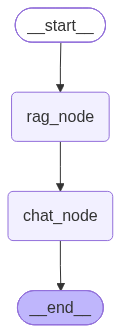

In [84]:
chatbot

In [85]:
result = chatbot.invoke({
    "messages": [],
    "query": "What type of influencers does this campaign require?",
    "context": ""
})

print(result["messages"][-1].content)

The campaign is looking for influencers who meet **all** of the following criteria:

- **Platforms:** Active on **Instagram** and/or **YouTube**.  
- **Followers:** At least **50,000** followers/subscribers.  
- **Views:** Average **20,000** views per post or video.  
- **Engagement:** Minimum **4 %** engagement rate.  
- **Likes:** Average **1,000** likes per post/video.  
- **Comments:** Average **50** comments per post/video.  

Only influencers who satisfy these thresholds are suitable for the campaign.
